# **ENVIROMENT INITIALIZATION**

In [40]:
# IMPORTS
# Math libraries
import numpy as np
from scipy import stats
import pandas as pd
import polars as pl

# Plots
import matplotlib.pyplot as plt

# Technical libraries
from pathlib import Path
from datetime import date, timedelta, datetime
import json

# ML libraries
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, roc_auc_score, precision_recall_fscore_support, accuracy_score, classification_report, confusion_matrix
import optuna
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
# CONFIGURATION
from config import (
    PROJECT_ROOT,
    DATA_PROCESSED_DIR, DATA_FEATURES_DIR,
    CV_FEATURES_PATH,
    REPORTS_DIR,
    REPORTS_MODELS_DIR, REPORTS_MODELS_GRAPHS_DIR, REPORTS_MODELS_LOGS_DIR,
    MODELS_DIR,
    RANDOM_STATE
)

In [24]:
# DATA PREPARING
all_features = pl.read_parquet(CV_FEATURES_PATH)

feature_cols = [c for c in all_features.columns if c not in ["user_id", "target"]]

X = all_features[feature_cols].to_numpy()
y = all_features["target"].to_numpy()
user_ids = all_features["user_id"].to_numpy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Users with positive target: {(y > 0).sum()}, ({(y > 0).sum() / 2500:.2f}%)")
print(f"Users with zero target: {(y == 0).sum()}, ({(y == 0).sum() / 2500:.2f}%)")

X shape: (250000, 133)
y shape: (250000,)
Users with positive target: 135165, (54.07%)
Users with zero target: 114835, (45.93%)


# **MODELS LEARNING**

## **DESIGN 1: BINARY CLASSIFIER + POSITIVE SHARES REGRESSOR**

In [25]:
# PREPARE CLASSIFICATION DATA
# Classification: all users, target = 1 if gmv > 0, otherwise 0
X_clf = X
y_clf = (y > 0).astype(int) # Binary target: 1 if a purchase, 0 if not

print(f"\nClassification X shape: {X_clf.shape}")
print(f"Classification y distribution: {np.bincount(y_clf)}")
print(f"Positive class ratio: {y_clf.mean():.4f}")

# PREPARE REGRESSION DATA
# Regression: only users with gmv > 0, target = log1p(gmv)
# Mask for users with a positive target
positive_mask = y > 0

X_reg = X[positive_mask]
y_reg_raw = y[positive_mask]
y_reg = np.log1p(y_reg_raw)

print(f"\nRegression X shape: {X_reg.shape}")
print(f"Regression y (log1p) mean: {y_reg.mean():.4f}")
print(f"Regression y (raw) mean: {y_reg_raw.mean():.4f}")


Classification X shape: (250000, 133)
Classification y distribution: [114835 135165]
Positive class ratio: 0.5407

Regression X shape: (135165, 133)
Regression y (log1p) mean: 4.1470
Regression y (raw) mean: 155.4286


In [26]:
# BINARY CLASSIFIER
# Split into train/val for classification
X_clf_train, X_clf_val, y_clf_train, y_clf_val = train_test_split(
    X_clf, y_clf, test_size = 0.2, random_state = RANDOM_STATE, stratify = y_clf
)

print(f"Train size: {len(X_clf_train)}")
print(f"Val size: {len(X_clf_val)}")

# Create datasets for LightGBM
train_data_clf = lgb.Dataset(X_clf_train, label = y_clf_train)
val_data_clf = lgb.Dataset(X_clf_val, label = y_clf_val, reference = train_data_clf)

# Parameters for classification
params_clf = {
    "objective": "binary",
    "metric": "binary_logloss",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "max_depth": -1,
    "min_child_samples": 100,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "verbose": -1,
    "n_jobs": -1,
}

# Train the classifier
clf = lgb.train(
    params_clf,
    train_data_clf,
    num_boost_round = 1000,
    valid_sets = [train_data_clf, val_data_clf],
    valid_names = ["train", "val"],
    callbacks=[
        lgb.early_stopping(stopping_rounds = 50),
        lgb.log_evaluation(period = 100),
    ],
)

print(f"\nBest iteration: {clf.best_iteration}")

# EVALUATE CLASSIFIER
# Predict probabilities
y_clf_train_pred = clf.predict(X_clf_train)
y_clf_val_pred = clf.predict(X_clf_val)

# AUC
train_auc = roc_auc_score(y_clf_train, y_clf_train_pred)
val_auc = roc_auc_score(y_clf_val, y_clf_val_pred)

print(f"Train AUC: {train_auc:.4f}")
print(f"Val AUC: {val_auc:.4f}")

# Precision, Recall, F1 (with threshold 0.5)
y_clf_val_pred_binary = (y_clf_val_pred > 0.5).astype(int)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_clf_val, y_clf_val_pred_binary, average = "binary"
)

print(f"Val Precision: {precision:.4f}")
print(f"Val Recall: {recall:.4f}")
print(f"Val F1: {f1:.4f}")

Train size: 200000
Val size: 50000
Training until validation scores don't improve for 50 rounds
[100]	train's binary_logloss: 0.457968	val's binary_logloss: 0.467484
Early stopping, best iteration is:
[148]	train's binary_logloss: 0.451069	val's binary_logloss: 0.467296

Best iteration: 148
Train AUC: 0.8677
Val AUC: 0.8571
Val Precision: 0.7927
Val Recall: 0.7902
Val F1: 0.7915


In [27]:
# REGRESSOR
# Splitting into train/val for regression
X_reg_train, X_reg_val, y_reg_train, y_reg_val = train_test_split(
    X_reg, y_reg, test_size = 0.2, random_state = RANDOM_STATE
)

print(f"Train size: {len(X_reg_train)}")
print(f"Val size: {len(X_reg_val)}")

# Creating datasets for LightGBM
train_data_reg = lgb.Dataset(X_reg_train, label = y_reg_train)
val_data_reg = lgb.Dataset(X_reg_val, label = y_reg_val, reference = train_data_reg)

# Parameters for regression
params_reg = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.05,
    "num_leaves": 63,
    "max_depth": -1,
    "min_child_samples": 100,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 0.1,
    "verbose": -1,
    "n_jobs": -1,
}

# Training the regressor
reg = lgb.train(
    params_reg,
    train_data_reg,
    num_boost_round = 1000,
    valid_sets=[train_data_reg, val_data_reg],
    valid_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(stopping_rounds = 50),
        lgb.log_evaluation(period = 100),
    ],
)

print(f"\nBest iteration: {reg.best_iteration}")

# EVALUATE REGRESSOR
# Predict in logarithmic space
y_reg_train_pred = reg.predict(X_reg_train)
y_reg_val_pred = reg.predict(X_reg_val)

# RMSE in logarithmic space (this is the RMSLE)
train_rmse_log = np.sqrt(mean_squared_error(y_reg_train, y_reg_train_pred))
val_rmse_log = np.sqrt(mean_squared_error(y_reg_val, y_reg_val_pred))

print(f"Train RMSE (log space): {train_rmse_log:.4f}")
print(f"Val RMSE (log space): {val_rmse_log:.4f}")

# RMSE in the original space (for interpretation)
# Convert predictions back to original scale
y_reg_train_pred_raw = np.expm1(y_reg_train_pred)
y_reg_val_pred_raw = np.expm1(y_reg_val_pred)

# Convert true values back to original scale
y_reg_train_raw = np.expm1(y_reg_train)
y_reg_val_raw = np.expm1(y_reg_val)

# Now calculate RMSE in original space
train_rmse_raw = np.sqrt(mean_squared_error(y_reg_train_raw, y_reg_train_pred_raw))
val_rmse_raw = np.sqrt(mean_squared_error(y_reg_val_raw, y_reg_val_pred_raw))

print(f"\nTrain RMSE (raw): {train_rmse_raw:.4f}")
print(f"Val RMSE (raw): {val_rmse_raw:.4f}")

Train size: 108132
Val size: 27033
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 1.07146	val's rmse: 1.10716
[200]	train's rmse: 1.04447	val's rmse: 1.10748
Early stopping, best iteration is:
[156]	train's rmse: 1.05574	val's rmse: 1.10697

Best iteration: 156
Train RMSE (log space): 1.0557
Val RMSE (log space): 1.1070

Train RMSE (raw): 332.8542
Val RMSE (raw): 290.9919


In [28]:
# COMBINE PREDICTIONS
# Predicting purchase probabilities for all users
P_buy = clf.predict(X)

# Predicting GMV for all users
predicted_gmv_log = reg.predict(X)
predicted_gmv = np.expm1(predicted_gmv_log)

# Final prediction: probability × amount
final_prediction = P_buy * predicted_gmv

# Обрезаем отрицательные значения
final_prediction = np.clip(final_prediction, 0, None)

print(f"Final prediction mean: {final_prediction.mean():.4f}")
print(f"Final prediction median: {np.median(final_prediction):.4f}")
print(f"Final prediction max: {final_prediction.max():.4f}")

# EVALUATE OVERALL QUALITY
def rmsle(y_true, y_pred):
    """Root Mean Squared Logarithmic Error"""
    y_true = np.asarray(y_true, dtype = np.float64)
    y_pred = np.asarray(y_pred, dtype = np.float64)
    y_pred = np.clip(y_pred, 0, None)
    
    return np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred)) ** 2))

# Calculating RMSLE on the entire dataset
overall_rmsle = rmsle(y, final_prediction)

print(f"\nOverall RMSLE: {overall_rmsle:.4f}\n")

# BASELINE COMPARISON
# Baseline 1: predicting mean
baseline_1 = np.full_like(y, y.mean())
baseline_1_rmsle = rmsle(y, baseline_1)
print(f"Baseline 1 (mean): {baseline_1_rmsle:.4f}")

# Baseline 2: predicting median
baseline_2 = np.full_like(y, np.median(y))
baseline_2_rmsle = rmsle(y, baseline_2)
print(f"Baseline 2 (median): {baseline_2_rmsle:.4f}")

# Baseline 3: predicting 0 for everyone
baseline_3 = np.zeros_like(y)
baseline_3_rmsle = rmsle(y, baseline_3)
print(f"Baseline 3 (zero): {baseline_3_rmsle:.4f}")

# Our model
print(f"Our model: {overall_rmsle:.4f}")

print("\nSUMMARY")
print(f"Classifier AUC: {val_auc:.4f}")
print(f"Regressor RMSE (log): {val_rmse_log:.4f}")
print(f"Overall RMSLE: {overall_rmsle:.4f}")
print(f"Baseline (mean) RMSLE: {baseline_1_rmsle:.4f}")
print(f"Improvement over baseline: {(baseline_1_rmsle - overall_rmsle) / baseline_1_rmsle * 100:.2f}%")

Final prediction mean: 48.6393
Final prediction median: 19.8121
Final prediction max: 2887.9119

Overall RMSLE: 1.8905

Baseline 1 (mean): 3.1750
Baseline 2 (median): 2.2890
Baseline 3 (zero): 3.2036
Our model: 1.8905

SUMMARY
Classifier AUC: 0.8571
Regressor RMSE (log): 1.1070
Overall RMSLE: 1.8905
Baseline (mean) RMSLE: 3.1750
Improvement over baseline: 40.46%


In [29]:
# FEATURE IMPORTANCE
feature_importance_clf = pd.DataFrame({
    "feature": feature_cols,
    "importance": clf.feature_importance(importance_type = "gain"),
}).sort_values("importance", ascending = False)

print("Top 20 features (classifier):")
print(feature_importance_clf.head(20))

feature_importance_reg = pd.DataFrame({
    "feature": feature_cols,
    "importance": reg.feature_importance(importance_type = "gain"),
}).sort_values("importance", ascending = False)

print("\nTop 20 features (regressor):")
print(feature_importance_reg.head(20))

Top 20 features (classifier):
                   feature     importance
26              orders_90d  448102.891344
115       orders_90d_right  138289.098239
69   non_salary_day_orders   96598.052499
1            recency_order   74439.454789
52          weekday_orders   56124.379207
22              orders_60d    8301.029588
5           active_days_7d    7448.696362
13         active_days_28d    6073.829014
66   orders_per_active_day    5930.084885
62      search_to_ord_rate    5310.688779
2             recency_cart    4942.699194
0         recency_activity    4676.832080
63        cart_to_ord_rate    4508.648537
59     weekend_order_share    4205.468316
44                 gmv_90d    3814.804602
17         active_days_30d    3781.414557
9          active_days_14d    3762.974904
111       orders_60d_right    3635.546250
48            weekday_days    3249.814736
21         active_days_60d    3200.923743

Top 20 features (regressor):
                   feature     importance
71      non_sala

### **OPTIMIZATION**

In [ ]:
# OPTIMIZATION: CLASSIFIER
print("CLASSIFIER OPTIMIZATION")

# Creating files for logs
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
clf_log_file = REPORTS_MODELS_LOGS_DIR / '01_lgbm_clf_reg' / f"clf_optimization_{timestamp}.log"
clf_params_file = REPORTS_MODELS_LOGS_DIR / '01_lgbm_clf_reg' / f"clf_best_params_{timestamp}.json"

print(f"Log file: {clf_log_file}")
print(f"Params file: {clf_params_file}")

# DEFINE OBJECTIVE FUNCTION
def objective_clf(trial):
    params = {
        "objective": "binary",
        "metric": "binary_logloss",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log = True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log = True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log = True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
        "verbose": -1,
        "n_jobs": -1,
    }
    
    train_data = lgb.Dataset(X_clf_train, label = y_clf_train)
    val_data = lgb.Dataset(X_clf_val, label = y_clf_val, reference = train_data)
    
    model = lgb.train(
        params,
        train_data,
        num_boost_round = 1000,
        valid_sets = [val_data],
        callbacks = [
            lgb.early_stopping(stopping_rounds = 50),
            lgb.log_evaluation(period = 0),
        ],
    )
    
    y_val_pred = model.predict(X_clf_val)
    auc = roc_auc_score(y_clf_val, y_val_pred)
    
    return auc

# RUN OPTIMIZATION
study_clf = optuna.create_study(
    direction = "maximize",
    study_name = "classifier_optimization",
    sampler = optuna.samplers.TPESampler(seed = RANDOM_STATE),
)

# We run the optimization (100 trials)
study_clf.optimize(objective_clf, n_trials = 100, show_progress_bar = True)

print(f"\nBest trial:")
print(f"  AUC: {study_clf.best_value:.4f}")
print(f"  Params: {study_clf.best_params}")

# SAVE LOGS
log_data = {
    "timestamp": timestamp,
    "best_auc": study_clf.best_value,
    "best_params": study_clf.best_params,
    "n_trials": len(study_clf.trials),
    "all_trials": [
        {
            "trial_number": t.number,
            "value": t.value,
            "params": t.params,
        }
        for t in study_clf.trials
    ],
}

with open(clf_log_file, "w") as f:
    json.dump(log_data, f, indent = 2)

with open(clf_params_file, "w") as f:
    json.dump(study_clf.best_params, f, indent = 2)

print(f"\nLogs saved to: {clf_log_file}")
print(f"Best params saved to: {clf_params_file}")

# TRAIN FINAL MODEL WITH BEST PARAMS
best_params_clf = study_clf.best_params.copy()
best_params_clf.update({
    "objective": "binary",
    "metric": "binary_logloss",
    "verbose": -1,
    "n_jobs": -1,
})

train_data_clf = lgb.Dataset(X_clf_train, label = y_clf_train)
val_data_clf = lgb.Dataset(X_clf_val, label = y_clf_val, reference = train_data_clf)

clf_optimized = lgb.train(
    best_params_clf,
    train_data_clf,
    num_boost_round = 1000,
    valid_sets = [train_data_clf, val_data_clf],
    valid_names = ["train", "val"],
    callbacks = [
        lgb.early_stopping(stopping_rounds = 50),
        lgb.log_evaluation(period = 100),
    ],
)

# Evaluate
y_clf_val_pred_opt = clf_optimized.predict(X_clf_val)
val_auc_opt = roc_auc_score(y_clf_val, y_clf_val_pred_opt)

print(f"\nOptimized Classifier AUC: {val_auc_opt:.4f}")

# SAVE MODEL
clf_model_path = MODELS_DIR / '01_lgbm_clf_reg' / f"clf_lightgbm_{timestamp}.txt"
clf_optimized.save_model(str(clf_model_path))
print(f"Model saved to: {clf_model_path}")

[I 2026-08-24 18:15:11,695] A new study created in memory with name: classifier_optimization


CLASSIFIER OPTIMIZATION
Log file: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\models\logs\clf_optimization_20260824_181511.log
Params file: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\models\logs\clf_best_params_20260824_181511.json


  0%|          | 0/100 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[321]	valid_0's binary_logloss: 0.467436


Best trial: 0. Best value: 0.856993:   1%|          | 1/100 [00:12<20:35, 12.48s/it]

...

[I 2026-08-24 18:47:54,445] Trial 97 finished with value: 0.8572097587593939 and parameters: {'learning_rate': 0.012960403293321984, 'num_leaves': 221, 'max_depth': 6, 'min_child_samples': 33, 'subsample': 0.8085534461949797, 'colsample_bytree': 0.7473632123536778, 'reg_alpha': 0.0003950384734003831, 'reg_lambda': 0.9824727306922038, 'min_split_gain': 0.7885055014037414}. Best is trial 81 with value: 0.857293313703426.
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[388]	valid_0's binary_logloss: 0.467139


Best trial: 81. Best value: 0.857293:  99%|█████████▉| 99/100 [33:01<00:20, 20.72s/it]

[I 2026-08-24 18:48:12,869] Trial 98 finished with value: 0.857131880555316 and parameters: {'learning_rate': 0.015758529566296642, 'num_leaves': 205, 'max_depth': 7, 'min_child_samples': 55, 'subsample': 0.7386573562649184, 'colsample_bytree': 0.651387702040155, 'reg_alpha': 0.0002360809845086224, 'reg_lambda': 1.5761832358890921, 'min_split_gain': 0.8799614365040367}. Best is trial 81 with value: 0.857293313703426.
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[606]	valid_0's binary_logloss: 0.466972


Best trial: 81. Best value: 0.857293: 100%|██████████| 100/100 [33:31<00:00, 20.12s/it]


[I 2026-08-24 18:48:43,297] Trial 99 finished with value: 0.857228687131629 and parameters: {'learning_rate': 0.01053010628676392, 'num_leaves': 194, 'max_depth': 8, 'min_child_samples': 41, 'subsample': 0.7225576885649363, 'colsample_bytree': 0.6353238866659321, 'reg_alpha': 0.0005624761896910156, 'reg_lambda': 5.084216208553236, 'min_split_gain': 0.5172442703676198}. Best is trial 81 with value: 0.857293313703426.

Best trial:
  AUC: 0.8573
  Params: {'learning_rate': 0.013465895801890577, 'num_leaves': 221, 'max_depth': 7, 'min_child_samples': 26, 'subsample': 0.7676589614561762, 'colsample_bytree': 0.6269609978683928, 'reg_alpha': 0.37887131221762604, 'reg_lambda': 4.246289225511034, 'min_split_gain': 0.9924008325519492}

Logs saved to: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\models\logs\clf_optimization_20260824_181511.log
Best params saved to: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\models\logs\clf_best_params_20260824_181511.

In [ ]:
# OPTIMIZATION: REGRESSOR
print("REGRESSOR OPTIMIZATION")

# Creating files for logs
reg_log_file = REPORTS_MODELS_LOGS_DIR / '01_lgbm_clf_reg' / f"reg_optimization_{timestamp}.log"
reg_params_file = REPORTS_MODELS_LOGS_DIR / '01_lgbm_clf_reg' / f"reg_best_params_{timestamp}.json"

print(f"Log file: {reg_log_file}")
print(f"Params file: {reg_params_file}")

# DEFINE OBJECTIVE FUNCTION
def objective_reg(trial):
    params = {
        "objective": "regression",
        "metric": "rmse",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log = True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log = True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log = True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
        "verbose": -1,
        "n_jobs": -1,
    }
    
    train_data = lgb.Dataset(X_reg_train, label = y_reg_train)
    val_data = lgb.Dataset(X_reg_val, label = y_reg_val, reference = train_data)
    
    model = lgb.train(
        params,
        train_data,
        num_boost_round = 1000,
        valid_sets = [val_data],
        callbacks = [
            lgb.early_stopping(stopping_rounds = 50),
            lgb.log_evaluation(period = 0),
        ],
    )
    
    y_val_pred = model.predict(X_reg_val)
    rmse = np.sqrt(mean_squared_error(y_reg_val, y_val_pred))
    
    return rmse # Minimizing RMSE

# RUN OPTIMIZATION
study_reg = optuna.create_study(
    direction = "minimize", # Minimizing for regression
    study_name = "regressor_optimization",
    sampler = optuna.samplers.TPESampler(seed = RANDOM_STATE),
)

# Running the optimization (100 trials)
study_reg.optimize(objective_reg, n_trials = 100, show_progress_bar = True)

print(f"\nBest trial:")
print(f"  RMSE: {study_reg.best_value:.4f}")
print(f"  Params: {study_reg.best_params}")

# SAVE LOGS
log_data_reg = {
    "timestamp": timestamp,
    "best_rmse": study_reg.best_value,
    "best_params": study_reg.best_params,
    "n_trials": len(study_reg.trials),
    "all_trials": [
        {
            "trial_number": t.number,
            "value": t.value,
            "params": t.params,
        }
        for t in study_reg.trials
    ],
}

with open(reg_log_file, "w") as f:
    json.dump(log_data_reg, f, indent = 2)

with open(reg_params_file, "w") as f:
    json.dump(study_reg.best_params, f, indent = 2)

print(f"\nLogs saved to: {reg_log_file}")
print(f"Best params saved to: {reg_params_file}")

# TRAIN FINAL MODEL WITH BEST PARAMS
best_params_reg = study_reg.best_params.copy()
best_params_reg.update({
    "objective": "regression",
    "metric": "rmse",
    "verbose": -1,
    "n_jobs": -1,
})

train_data_reg = lgb.Dataset(X_reg_train, label = y_reg_train)
val_data_reg = lgb.Dataset(X_reg_val, label = y_reg_val, reference = train_data_reg)

reg_optimized = lgb.train(
    best_params_reg,
    train_data_reg,
    num_boost_round = 1000,
    valid_sets = [train_data_reg, val_data_reg],
    valid_names = ["train", "val"],
    callbacks = [
        lgb.early_stopping(stopping_rounds = 50),
        lgb.log_evaluation(period = 100),
    ],
)

# Evaluate
y_reg_val_pred_opt = reg_optimized.predict(X_reg_val)
val_rmse_log_opt = np.sqrt(mean_squared_error(y_reg_val, y_reg_val_pred_opt))

print(f"\nOptimized Regressor RMSE (log): {val_rmse_log_opt:.4f}")

# SAVE MODEL
reg_model_path = MODELS_DIR / '01_lgbm_clf_reg' / f"reg_lightgbm_{timestamp}.txt"
reg_optimized.save_model(str(reg_model_path))
print(f"Model saved to: {reg_model_path}")

[I 2026-08-24 18:49:07,267] A new study created in memory with name: regressor_optimization


REGRESSOR OPTIMIZATION
Log file: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\models\logs\reg_optimization_20260824_181511.log
Params file: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\models\logs\reg_best_params_20260824_181511.json


  0%|          | 0/100 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds


Best trial: 0. Best value: 1.10576:   1%|          | 1/100 [00:07<12:08,  7.36s/it]

...

Early stopping, best iteration is:
[240]	valid_0's rmse: 1.10612
[I 2026-08-24 18:59:22,270] Trial 97 finished with value: 1.1061246103162228 and parameters: {'learning_rate': 0.027061202026033373, 'num_leaves': 79, 'max_depth': 10, 'min_child_samples': 25, 'subsample': 0.7309393834127081, 'colsample_bytree': 0.8361412437994851, 'reg_alpha': 3.8139975367266383, 'reg_lambda': 0.3737364604922605, 'min_split_gain': 0.3401591503156114}. Best is trial 91 with value: 1.105166119712674.
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[729]	valid_0's rmse: 1.10541


Best trial: 91. Best value: 1.10517:  99%|█████████▉| 99/100 [10:24<00:07,  7.87s/it]

[I 2026-08-24 18:59:31,754] Trial 98 finished with value: 1.1054141450988382 and parameters: {'learning_rate': 0.02153121595909057, 'num_leaves': 59, 'max_depth': 4, 'min_child_samples': 29, 'subsample': 0.7822250770357752, 'colsample_bytree': 0.8707303123909044, 'reg_alpha': 7.026245952248933e-08, 'reg_lambda': 0.03691470773557635, 'min_split_gain': 0.30850713157627874}. Best is trial 91 with value: 1.105166119712674.
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[592]	valid_0's rmse: 1.10556


Best trial: 91. Best value: 1.10517: 100%|██████████| 100/100 [10:34<00:00,  6.34s/it]


[I 2026-08-24 18:59:41,602] Trial 99 finished with value: 1.1055590525201897 and parameters: {'learning_rate': 0.021358690924240913, 'num_leaves': 31, 'max_depth': 5, 'min_child_samples': 31, 'subsample': 0.7919367226018323, 'colsample_bytree': 0.8796199825637038, 'reg_alpha': 6.282150337537951e-08, 'reg_lambda': 0.028891896894101404, 'min_split_gain': 0.25195240398974417}. Best is trial 91 with value: 1.105166119712674.

Best trial:
  RMSE: 1.1052
  Params: {'learning_rate': 0.035509929827529076, 'num_leaves': 62, 'max_depth': 4, 'min_child_samples': 24, 'subsample': 0.6964721001875976, 'colsample_bytree': 0.77715088718818, 'reg_alpha': 3.32559077926133, 'reg_lambda': 0.012935859369926927, 'min_split_gain': 0.20664293830319938}

Logs saved to: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\models\logs\reg_optimization_20260824_181511.log
Best params saved to: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\models\logs\reg_best_params_20260824_181

In [51]:
# COMPARE ORIGINAL vs OPTIMIZED
print("COMPARISON: ORIGINAL vs OPTIMIZED")

# Classifier comparison
print("\nCLASSIFIER")
print(f"Original AUC: {val_auc:.4f}")
print(f"Optimized AUC: {val_auc_opt:.4f}")
print(f"Improvement: {(val_auc_opt - val_auc) / val_auc * 100:.2f}%")

# Regressor comparison
print("\nREGRESSOR")
print(f"Original RMSE (log): {val_rmse_log:.4f}")
print(f"Optimized RMSE (log): {val_rmse_log_opt:.4f}")
print(f"Improvement: {(val_rmse_log - val_rmse_log_opt) / val_rmse_log * 100:.2f}%")

# Overall comparison
print("\nOVERALL")
# Using optimized models for final prediction
P_buy_opt = clf_optimized.predict(X)
predicted_gmv_log_opt = reg_optimized.predict(X)
predicted_gmv_opt = np.expm1(predicted_gmv_log_opt)
final_prediction_opt = P_buy_opt * predicted_gmv_opt
final_prediction_opt = np.clip(final_prediction_opt, 0, None)

overall_rmsle_opt = rmsle(y, final_prediction_opt)

print(f"Original RMSLE: {overall_rmsle:.4f}")
print(f"Optimized RMSLE: {overall_rmsle_opt:.4f}")
print(f"Improvement: {(overall_rmsle - overall_rmsle_opt) / overall_rmsle * 100:.2f}%")

COMPARISON: ORIGINAL vs OPTIMIZED

CLASSIFIER
Original AUC: 0.8571
Optimized AUC: 0.8573
Improvement: 0.03%

REGRESSOR
Original RMSE (log): 1.1070
Optimized RMSE (log): 1.1052
Improvement: 0.16%

OVERALL
Original RMSLE: 1.8905
Optimized RMSLE: 1.8946
Improvement: -0.22%


FEATURE IMPORTANCE (OPTIMIZED MODELS)

Top 20 features (optimized classifier):
                   feature    importance
26              orders_90d  1.446304e+06
115       orders_90d_right  5.117311e+05
69   non_salary_day_orders  4.093589e+05
52          weekday_orders  2.784492e+05
1            recency_order  2.536331e+05
22              orders_60d  6.988275e+04
44                 gmv_90d  2.962758e+04
66   orders_per_active_day  2.790417e+04
62      search_to_ord_rate  2.122962e+04
111       orders_60d_right  2.085323e+04
5           active_days_7d  1.963414e+04
63        cart_to_ord_rate  1.772587e+04
2             recency_cart  1.688347e+04
17         active_days_30d  1.604715e+04
13         active_days_28d  1.576856e+04
0         recency_activity  1.432848e+04
48            weekday_days  1.401806e+04
3           recency_search  1.353042e+04
59     weekend_order_share  1.153915e+04
57             weekday_gmv  1.096534e+04

Top 20 features (optimized regressor):
                   f

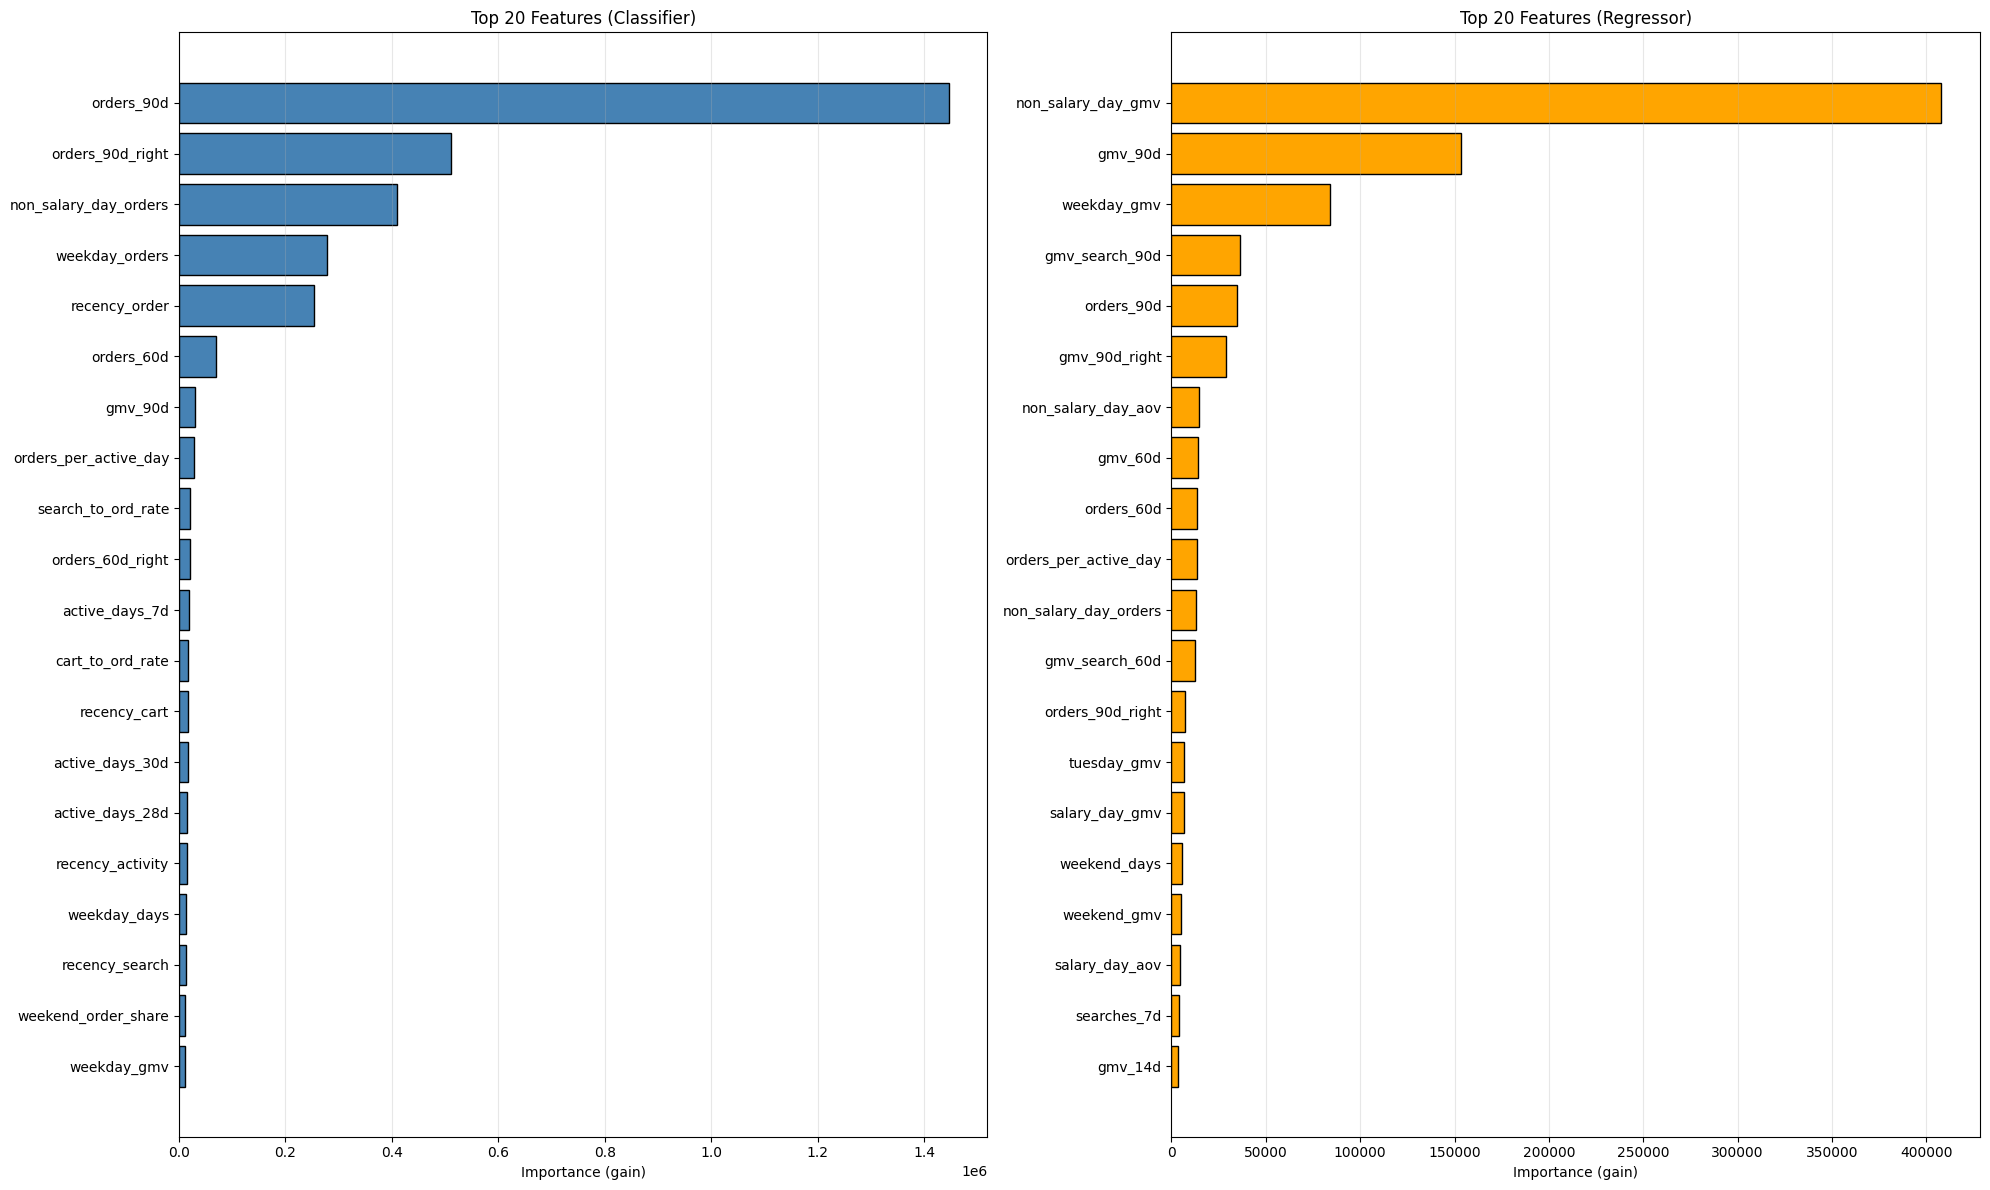


Feature importance plot saved to: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\models\graphs\01_lgbm_clf_reg\feature_importance_lgbm_clf_reg_optimized.png


In [62]:
# FEATURE IMPORTANCE (OPTIMIZED MODELS)
print("FEATURE IMPORTANCE (OPTIMIZED MODELS)")

# Classifier importance
feature_importance_clf_opt = pd.DataFrame({
    "feature": feature_cols,
    "importance": clf_optimized.feature_importance(importance_type = "gain"),
}).sort_values("importance", ascending = False)

print("\nTop 20 features (optimized classifier):")
print(feature_importance_clf_opt.head(20))

# Regressor importance
feature_importance_reg_opt = pd.DataFrame({
    "feature": feature_cols,
    "importance": reg_optimized.feature_importance(importance_type = "gain"),
}).sort_values("importance", ascending = False)

print("\nTop 20 features (optimized regressor):")
print(feature_importance_reg_opt.head(20))

# VISUALIZE FEATURE IMPORTANCE
fig, axes = plt.subplots(1, 2, figsize = (20, 12))

# Classifier importance plot
top_n = 20
axes[0].barh(
    feature_importance_clf_opt.head(top_n)["feature"],
    feature_importance_clf_opt.head(top_n)["importance"],
    color = "steelblue",
    edgecolor = "black"
)
axes[0].set_xlabel("Importance (gain)")
axes[0].set_title(f"Top {top_n} Features (Classifier)")
axes[0].grid(alpha = 0.3, axis = "x")
axes[0].invert_yaxis()

# Regressor importance plot
axes[1].barh(
    feature_importance_reg_opt.head(top_n)["feature"],
    feature_importance_reg_opt.head(top_n)["importance"],
    color = "orange",
    edgecolor = "black"
)
axes[1].set_xlabel("Importance (gain)")
axes[1].set_title(f"Top {top_n} Features (Regressor)")
axes[1].grid(alpha = 0.3, axis = "x")
axes[1].invert_yaxis()

plt.tight_layout()
fig.savefig(REPORTS_MODELS_GRAPHS_DIR / '01_lgbm_clf_reg' / "feature_importance_lgbm_clf_reg_optimized.png", dpi = 150)
plt.show()

print(f"\nFeature importance plot saved to: {REPORTS_MODELS_GRAPHS_DIR / '01_lgbm_clf_reg' / 'feature_importance_lgbm_clf_reg_optimized.png'}")

CONFUSION MATRIX (CLASSIFIER)

Confusion Matrix:
[[17359  5608]
 [ 5641 21392]]

True Negatives: 17359
False Positives: 5608
False Negatives: 5641
True Positives: 21392


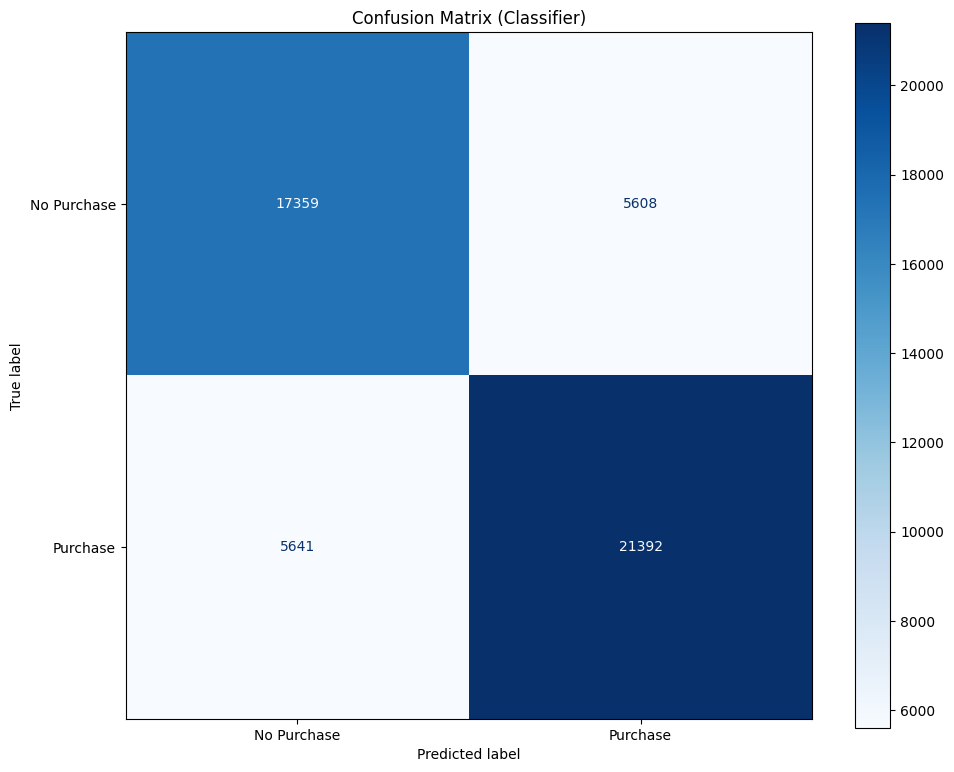

Confusion matrix saved to: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\models\graphs\01_lgbm_clf_reg\confusion_matrix_lgbm_clf.png


In [61]:
# CONFUSION MATRIX (CLASSIFIER)
print("CONFUSION MATRIX (CLASSIFIER)")

# Predicting on validation
y_clf_val_pred_opt_binary = (y_clf_val_pred_opt > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y_clf_val, y_clf_val_pred_opt_binary)

print("\nConfusion Matrix:")
print(cm)
print(f"\nTrue Negatives: {cm[0, 0]}")
print(f"False Positives: {cm[0, 1]}")
print(f"False Negatives: {cm[1, 0]}")
print(f"True Positives: {cm[1, 1]}")

# Visualization
fig, ax = plt.subplots(figsize = (10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["No Purchase", "Purchase"])
disp.plot(cmap = "Blues", ax = ax)
ax.set_title("Confusion Matrix (Classifier)")
plt.tight_layout()
fig.savefig(REPORTS_MODELS_GRAPHS_DIR / '01_lgbm_clf_reg' / "confusion_matrix_lgbm_clf.png", dpi = 150)
plt.show()

print(f"Confusion matrix saved to: {REPORTS_MODELS_GRAPHS_DIR / '01_lgbm_clf_reg' / 'confusion_matrix_lgbm_clf.png'}")

PREDICTION DISTRIBUTION (REGRESSOR)


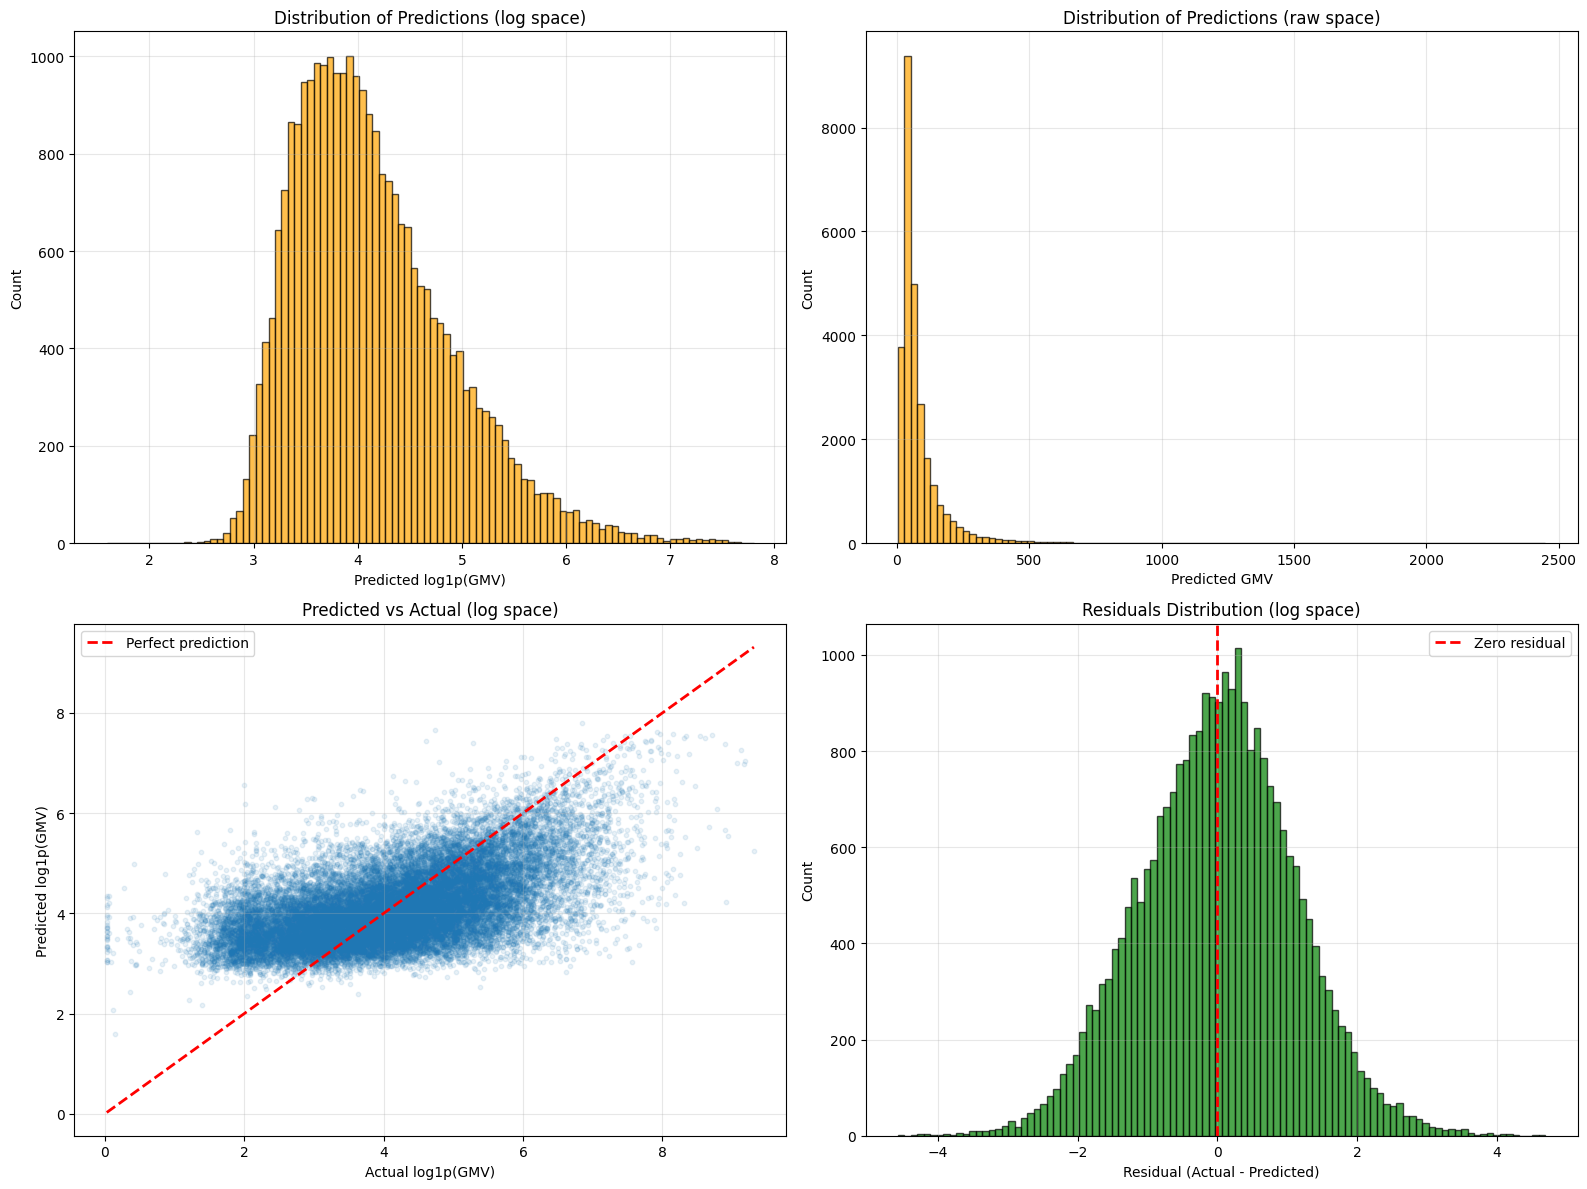

Regressor predictions saved to: D:\.workspace\Programming\Projects\E-cup_2026_by_Ozon_Tech\reports\models\graphs\01_lgbm_clf_reg\lgbm_reg_predictions.png

Residuals statistics (log space):
  Mean: 0.0038
  Std: 1.1052
  Min: -4.5681
  Max: 4.6917


In [60]:
# PREDICTION DISTRIBUTION (REGRESSOR)
print("PREDICTION DISTRIBUTION (REGRESSOR)")

# Validation predictions (in logarithmic space)
y_reg_val_pred_opt_log = reg_optimized.predict(X_reg_val)
y_reg_val_pred_opt_raw = np.expm1(y_reg_val_pred_opt_log)
y_reg_val_raw = np.expm1(y_reg_val)

fig, axes = plt.subplots(2, 2, figsize = (16, 12))

# Graph 1: Prediction distribution (log space)
axes[0, 0].hist(y_reg_val_pred_opt_log, bins = 100, alpha = 0.7, edgecolor = "black", color = "orange")
axes[0, 0].set_title("Distribution of Predictions (log space)")
axes[0, 0].set_xlabel("Predicted log1p(GMV)")
axes[0, 0].set_ylabel("Count")
axes[0, 0].grid(alpha = 0.3)

# Graph 2: Prediction distribution (raw space)
axes[0, 1].hist(y_reg_val_pred_opt_raw, bins = 100, alpha = 0.7, edgecolor = "black", color = "orange")
axes[0, 1].set_title("Distribution of Predictions (raw space)")
axes[0, 1].set_xlabel("Predicted GMV")
axes[0, 1].set_ylabel("Count")
axes[0, 1].grid(alpha = 0.3)

# Graph 3: Prediction vs Reality (log space)
axes[1, 0].scatter(y_reg_val, y_reg_val_pred_opt_log, alpha = 0.1, s = 10)
axes[1, 0].plot([y_reg_val.min(), y_reg_val.max()], [y_reg_val.min(), y_reg_val.max()], "r--", linewidth = 2, label = "Perfect prediction")
axes[1, 0].set_title("Predicted vs Actual (log space)")
axes[1, 0].set_xlabel("Actual log1p(GMV)")
axes[1, 0].set_ylabel("Predicted log1p(GMV)")
axes[1, 0].legend()
axes[1, 0].grid(alpha = 0.3)

# Graph 4: Remaining space (log space)
residuals_log = y_reg_val - y_reg_val_pred_opt_log
axes[1, 1].hist(residuals_log, bins = 100, alpha = 0.7, edgecolor = "black", color = "green")
axes[1, 1].set_title("Residuals Distribution (log space)")
axes[1, 1].set_xlabel("Residual (Actual - Predicted)")
axes[1, 1].set_ylabel("Count")
axes[1, 1].axvline(0, color = "red", linestyle = "--", linewidth = 2, label = "Zero residual")
axes[1, 1].legend()
axes[1, 1].grid(alpha = 0.3)

plt.tight_layout()
fig.savefig(REPORTS_MODELS_GRAPHS_DIR / '01_lgbm_clf_reg' / "lgbm_reg_predictions.png", dpi = 150)
plt.show()

print(f"Regressor predictions saved to: {REPORTS_MODELS_GRAPHS_DIR / '01_lgbm_clf_reg' / 'lgbm_reg_predictions.png'}")

# Статистика остатков
print("\nResiduals statistics (log space):")
print(f"  Mean: {residuals_log.mean():.4f}")
print(f"  Std: {residuals_log.std():.4f}")
print(f"  Min: {residuals_log.min():.4f}")
print(f"  Max: {residuals_log.max():.4f}")

In [59]:
# ERROR ANALYSIS
print("ERROR ANALYSIS")

# Obtain predictions for all users
P_buy_all = clf_optimized.predict(X)
predicted_gmv_log_all = reg_optimized.predict(X)
predicted_gmv_all = np.expm1(predicted_gmv_log_all)
final_prediction_all = P_buy_all * predicted_gmv_all
final_prediction_all = np.clip(final_prediction_all, 0, None)

# Counting error for each user
errors = np.abs(y - final_prediction_all)
errors_log = np.abs(np.log1p(y) - np.log1p(final_prediction_all))

worst_indices = np.argsort(errors_log)[-10:][::-1]

print("\nTop 10 worst predictions:")
for idx in worst_indices:
    user_id = user_ids[idx]
    actual = y[idx]
    predicted = final_prediction_all[idx]
    error_log = errors_log[idx]
    
    print(f"User {user_id}:")
    print(f"  Actual GMV: {actual:.2f}")
    print(f"  Predicted GMV: {predicted:.2f}")
    print(f"  Error (log): {error_log:.4f}")
    print(f"  Error (raw): {errors[idx]:.2f}")
    print()

# Creating a table for analysis
analysis_df = pd.DataFrame({
    "user_id": user_ids,
    "actual": y,
    "predicted": final_prediction_all,
    "error_abs": errors,
    "error_log": errors_log,
})

# Error statistics
print("Error statistics:")
print(f"  Mean absolute error: {errors.mean():.2f}")
print(f"  Median absolute error: {np.median(errors):.2f}")
print(f"  Mean log error: {errors_log.mean():.4f}")
print(f"  Median log error: {np.median(errors_log):.4f}")

# Saving the table
analysis_path = REPORTS_MODELS_LOGS_DIR / '01_lgbm_clf_reg' / f"lgbm_clf_reg_error_analysis_{timestamp}.csv"
analysis_df.to_csv(analysis_path, index = False)
print(f"\nError analysis saved to: {analysis_path}")

ERROR ANALYSIS

Top 10 worst predictions:
User 355760:
  Actual GMV: 5408.92
  Predicted GMV: 3.90
  Error (log): 7.0069
  Error (raw): 5405.02

User 9355:
  Actual GMV: 0.00
  Predicted GMV: 1089.35
  Error (log): 6.9943
  Error (raw): 1089.35

User 878115:
  Actual GMV: 0.00
  Predicted GMV: 998.97
  Error (log): 6.9077
  Error (raw): 998.97

User 182646:
  Actual GMV: 0.00
  Predicted GMV: 928.92
  Error (log): 6.8351
  Error (raw): 928.92

User 493918:
  Actual GMV: 3135.53
  Predicted GMV: 2.68
  Error (log): 6.7466
  Error (raw): 3132.84

User 516209:
  Actual GMV: 0.00
  Predicted GMV: 808.73
  Error (log): 6.6967
  Error (raw): 808.73

User 537206:
  Actual GMV: 0.00
  Predicted GMV: 699.47
  Error (log): 6.5517
  Error (raw): 699.47

User 401208:
  Actual GMV: 0.00
  Predicted GMV: 647.18
  Error (log): 6.4742
  Error (raw): 647.18

User 531419:
  Actual GMV: 0.00
  Predicted GMV: 627.40
  Error (log): 6.4432
  Error (raw): 627.40

User 529470:
  Actual GMV: 2500.39
  Predicte